In [1]:
#import packages
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import os
print(os.getcwd())

/Users/arijit.banerjee/Desktop


In [2]:
df = pd.read_csv('/Users/arijit.banerjee/Downloads/superstore_dataset2011-2015.csv',encoding='ISO-8859-1')

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,42433,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,TB-11280,Toby Braunhardt,Consumer,Constantine,Constantine,...,OFF-TEN-10000025,Office Supplies,Storage,"Tenex Lockers, Blue",408.300,2,0.0,106.140,35.46,Medium
1,22253,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,JH-15985,Joseph Holt,Consumer,Wagga Wagga,New South Wales,...,OFF-SU-10000618,Office Supplies,Supplies,"Acme Trimmer, High Speed",120.366,3,0.1,36.036,9.72,Medium
2,48883,HU-2011-1220,1/1/2011,5/1/2011,Second Class,AT-735,Annie Thurman,Consumer,Budapest,Budapest,...,OFF-TEN-10001585,Office Supplies,Storage,"Tenex Box, Single Width",66.120,4,0.0,29.640,8.17,High
3,11731,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,EM-14140,Eugene Moren,Home Office,Stockholm,Stockholm,...,OFF-PA-10001492,Office Supplies,Paper,"Enermax Note Cards, Premium",44.865,3,0.5,-26.055,4.82,High
4,22255,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,JH-15985,Joseph Holt,Consumer,Wagga Wagga,New South Wales,...,FUR-FU-10003447,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",113.670,5,0.1,37.770,4.70,Medium


In [4]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country',
       'Postal Code', 'Market', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit', 'Shipping Cost', 'Order Priority'],
      dtype='object')

In [5]:
df.shape

(51290, 24)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  object 
 2   Order Date      51290 non-null  object 
 3   Ship Date       51290 non-null  object 
 4   Ship Mode       51290 non-null  object 
 5   Customer ID     51290 non-null  object 
 6   Customer Name   51290 non-null  object 
 7   Segment         51290 non-null  object 
 8   City            51290 non-null  object 
 9   State           51290 non-null  object 
 10  Country         51290 non-null  object 
 11  Postal Code     9994 non-null   float64
 12  Market          51290 non-null  object 
 13  Region          51290 non-null  object 
 14  Product ID      51290 non-null  object 
 15  Category        51290 non-null  object 
 16  Sub-Category    51290 non-null  object 
 17  Product Name    51290 non-null 

In [7]:
#check NULL values
df.isnull().sum()

Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
City                  0
State                 0
Country               0
Postal Code       41296
Market                0
Region                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Quantity              0
Discount              0
Profit                0
Shipping Cost         0
Order Priority        0
dtype: int64

In [8]:
#Check for dupliacted data and drop them
df.duplicated().any()

False

In [9]:
#drop not needed columns
df=df.drop(['Row ID','Order ID','Customer ID','Postal Code'],axis=1)

In [10]:
df.columns

Index(['Order Date', 'Ship Date', 'Ship Mode', 'Customer Name', 'Segment',
       'City', 'State', 'Country', 'Market', 'Region', 'Product ID',
       'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity',
       'Discount', 'Profit', 'Shipping Cost', 'Order Priority'],
      dtype='object')

In [11]:
#Profit by Category
cat_profit=df.groupby('Category')['Profit'].sum()

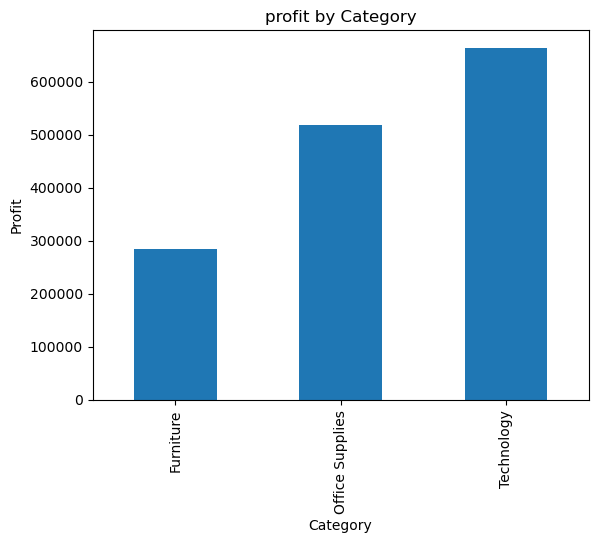

In [12]:
#ploting category by profit
cat_profit.plot(kind='bar')
plt.title("profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.show()

()

In [13]:
#which region has the highest sales 
sales_groupby_region=df.groupby('Region')['Sales'].sum()

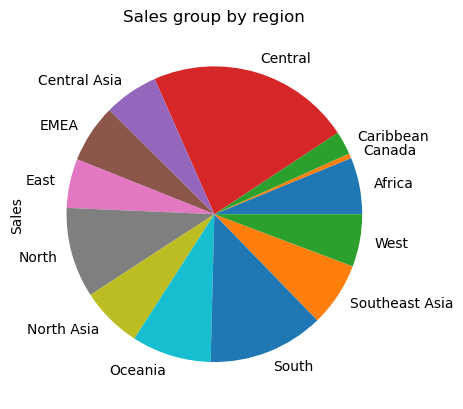

In [14]:
sales_groupby_region.plot(kind='pie')
plt.title("Sales group by region")
plt.show()

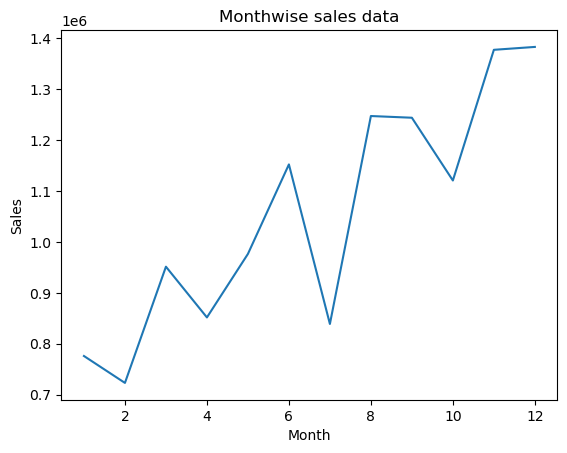

In [ ]:
df['Order Month']=pd.DatetimeIndex(df['Order Date']).month

month_sales=df.groupby('Order Month')['Sales'].sum()
month_sales.plot(kind='line')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.title("Monthwise  sales data")
plt.show()

In [115]:
#profit city-statewise sales for segment consumer
data=df[(df['Segment']=='Consumer') & ( df['Region']=='North') & (df['Sub-Category']=='Paper')].groupby(['City','State'])['Profit'].sum()
data.plot(kind='bar')
plt.rcParams['figure.figsize'] = [200, 80]
plt.title("Ciry and Statewise profit")
plt.xlabel("City")
plt.ylabel("profit")
plt.show()


In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order Date      51290 non-null  object 
 1   Ship Date       51290 non-null  object 
 2   Ship Mode       51290 non-null  object 
 3   Customer Name   51290 non-null  object 
 4   Segment         51290 non-null  object 
 5   City            51290 non-null  object 
 6   State           51290 non-null  object 
 7   Country         51290 non-null  object 
 8   Market          51290 non-null  object 
 9   Region          51290 non-null  object 
 10  Product ID      51290 non-null  object 
 11  Category        51290 non-null  object 
 12  Sub-Category    51290 non-null  object 
 13  Product Name    51290 non-null  object 
 14  Sales           51290 non-null  float64
 15  Quantity        51290 non-null  int64  
 16  Discount        51290 non-null  float64
 17  Profit          51290 non-null 

In [125]:
#Orders with sameday shiping have the lowest rate of returned
total_orders_by_shiping_mode=df.groupby('Ship Mode').size()
returned_order_by_shipping=df[df['Profit']<0].groupby('Ship Mode').size()
returned_order_by_shipping_per=(total_order_by_shiiping_mode / returned_order_by_shipping)*100 
print(returned_order_by_shipping_per)
returned_order_by_shipping_per.plot(kind="bar")
plt.title("Return per by shiping mode")
plt.xlabel("shiping mode")
plt.ylabel("return per")
plt.show

Ship Mode
First Class       398.777896
Same Day          418.111455
Second Class      415.350524
Standard Class    408.481550
dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

In [ ]:
df.columns
df['Order Day']=pd.DatetimeIndex(df['Order Date']).day_name()
day_profit=df.groupby('Order Day')['Profit'].sum()
day_profit.plot(kind='bar')
plt.xlabel('Days of week')
plt.ylabel('profit')  
plt.gca().set_xlabel(' Days of Weeks', fontsize=200)
plt.gca().set_ylabel('profit', fontsize=200)
plt.show()